# My Code 

In [ ]:
Main controlled baseline:
50% majority + square-root BCE + no augmentation + Dynamic 1:1 sampler + seed 42

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from timm.models.layers.helpers import to_2tuple
import timm
import random
import io
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt
import os
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score

# =========================
# Reproducibility control for controlled ablation
# =========================

SEED = 42

def set_seed(seed=42):
    import os
    import random
    import numpy as np
    import torch

    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More deterministic CUDA behaviour
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print(f"Controlled experiment seed fixed at: {SEED}")

# =========================
# Reproduction Config
# =========================

RUN_NAME = "controlled_seed42_50_sqrt_no_aug"
SEED = 42

# DICC project paths
PROJECT_ROOT = Path("/home/user/jiangjie/Jiangjie_Project")
RP50_DIR = PROJECT_ROOT / "data" / "ResearchProject_50"
CHECKPOINT_PATH = PROJECT_ROOT / "weights" / "ctranspath.pth"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "kee_reproduction" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Kee baseline settings
NUM_CLASSES = 12
EPOCHS = 50
LEARNING_RATE = 1e-5
BATCH_SIZE = 128
PATIENCE = 3
NUM_WORKERS = 8

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"RUN_NAME: {RUN_NAME}")
print(f"RP50_DIR exists: {RP50_DIR.exists()} -> {RP50_DIR}")
print(f"CHECKPOINT_PATH exists: {CHECKPOINT_PATH.exists()} -> {CHECKPOINT_PATH}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

# 12 OED morphological feature labels used in Kee CTransPath baseline
label_columns = [
    "Irregular epithelial stratification",
    "Loss of polarity of basal cells",
    "Drop shaped rete ridges",
    "Premature keratinization in single cells",
    "Loss of epithelial cell cohesion",
    "Abnormal variation in nuclear size",
    "Abnormal variation in nuclear shape",
    "Abnormal variation in cell size",
    "Abnormal variation in cell shape",
    "Increased N:C ratio",
    "Increased number and size of nucleoli",
    "Hyperchromasia",
]

print("Number of labels:", len(label_columns))

class PathBlur(object):
    def __init__(self, blur_sigma=(0.5, 2.0), poisson_scale=(5, 20), jpeg_quality=(30, 90)):
        self.blur_sigma = blur_sigma
        self.poisson_scale = poisson_scale
        self.jpeg_quality = jpeg_quality

    def __call__(self, img):
        # 1️⃣ Gaussian Blur
        sigma = random.uniform(*self.blur_sigma)
        img = img.filter(ImageFilter.GaussianBlur(radius=sigma))

        # 2️⃣ Poisson Noise
        np_img = np.array(img).astype(np.float32)
        scale = random.uniform(*self.poisson_scale)
        noisy = np.random.poisson(np_img * scale) / scale
        noisy = np.clip(noisy, 0, 255).astype(np.uint8)
        img = Image.fromarray(noisy)

        # 3️⃣ JPEG Compression Artifact
        buffer = io.BytesIO()
        quality = random.randint(*self.jpeg_quality)
        img.save(buffer, format='JPEG', quality=quality)
        img = Image.open(buffer)

        return img

# Fixed pre-processing applied to all data (Resize, ToTensor, Normalize)
base_transforms = [
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
]

# Validation/Test Transform (No Augmentation)
val_test_transform = transforms.Compose(base_transforms)

# Define different augmentation combinations
AUGMENTATION_COMBINATIONS = {
    'None': val_test_transform, # Baseline: No Augmentation

    # 'Random_Rotation': transforms.Compose([
    #     transforms.RandomApply(
    #         [transforms.RandomRotation(degrees=(-45, 45))],
    #         p=0.5    # 50% chance to apply rotation
    #     ),
    #     *base_transforms
    # ]),
    # # 'Random_Translation': transforms.Compose([
    # #     transforms.RandomAffine(
    # #         degrees=0,                # no rotation
    # #         translate=(70/224, 70/224)  # assuming images are 224×224
    # #     ),
    # #     *base_transforms
    # # ]),

    # 'Random_Cropping': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.RandomResizedCrop(
    #             size=224,
    #             scale=(0.7, 1.0),
    #             ratio=(1.0, 1.0)
    #         )
    #     ], p=0.5),  # 50% chance to randomly crop
    #     *base_transforms
    # ]),

    # 'Random_Flipping': transforms.Compose([
    #     transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip horizontally
    #     transforms.RandomVerticalFlip(p=0.5),    # 50% chance to flip vertically
    #     *base_transforms
    # ]),

    # 'Color_Augmentation': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.ColorJitter(
    #             brightness=0.1,
    #             contrast=0.1,
    #             saturation=0.1,
    #             hue=0.02
    #         ),
    #     ], p=0.5),
    #     *base_transforms
    # ]),

    # # 'Stain_Augmentation': transforms.Compose([
    # #     transforms.ColorJitter(
    # #         brightness=0.8,
    # #         contrast=0.8,
    # #         saturation=0.8,
    # #         hue=0.2
    # #     ),
    # #     transforms.RandomGrayscale(p=0.2),
    # #     *base_transforms
    # # ]),

    # # 'PathBlur_Augmentation': transforms.Compose([
    # #     PathBlur(
    # #         blur_sigma=(0.5, 2.0),
    # #         poisson_scale=(5, 20),
    # #         jpeg_quality=(30, 90)
    # #     ),
    # #     *base_transforms
    # # ]),

    # # 'Random_Cropping + Color_Augmentation': transforms.Compose([
    # #     transforms.RandomApply([
    # #         transforms.RandomResizedCrop(
    # #             size=224,
    # #             scale=(0.7, 1.0),
    # #             ratio=(1.0, 1.0)
    # #         ),
    # #         transforms.ColorJitter(
    # #             brightness=0.1,
    # #             contrast=0.1,
    # #             saturation=0.1,
    # #             hue=0.02
    # #         ),
    # #     ], p=0.5),
    # #     *base_transforms
    # # ]),

    # 'Random_Flipping + Color_Augmentation': transforms.Compose([
    #     transforms.RandomApply([
    #         transforms.RandomHorizontalFlip(p=0.5),
    #         transforms.RandomVerticalFlip(p=0.5),
    #         transforms.ColorJitter(
    #             brightness=0.1,
    #             contrast=0.1,
    #             saturation=0.1,
    #             hue=0.02
    #         ),
    #     ], p=0.5),
    #     *base_transforms
    # ])
}

/home/user/jiangjie/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Controlled experiment seed fixed at: 42
Using device: cuda
RUN_NAME: controlled_seed42_50_sqrt_no_aug
RP50_DIR exists: True -> /home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50
CHECKPOINT_PATH exists: True -> /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth
OUTPUT_DIR: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug
Number of labels: 12


In [2]:
# =========================
# Transform setting: Run A = no augmentation
# =========================

base_transforms = [
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
]

# Validation/Test Transform: no augmentation
val_test_transform = transforms.Compose(base_transforms)

# Run A: 50% Square-root Weight, no augmentation
AUGMENTATION_COMBINATIONS = {
    "None": val_test_transform
}

print("Augmentation setting:")
print(AUGMENTATION_COMBINATIONS)

Augmentation setting:
{'None': Compose(
    Resize(size=224, interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)}


In [3]:
# @title Original code

# --- 1. CTransPath Architecture (Swin + ConvStem) ---

class ConvStem(nn.Module):

    def __init__(self, img_size=224, patch_size=4, in_chans=3, embed_dim=768, norm_layer=None, flatten=True):
        super().__init__()

        assert patch_size == 4
        assert embed_dim % 8 == 0

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size = img_size
        self.patch_size = patch_size
        self.grid_size = (img_size[0] // patch_size[0], img_size[1] // patch_size[1])
        self.num_patches = self.grid_size[0] * self.grid_size[1]
        self.flatten = flatten


        stem = []
        input_dim, output_dim = 3, embed_dim // 8
        for l in range(2):
            stem.append(nn.Conv2d(input_dim, output_dim, kernel_size=3, stride=2, padding=1, bias=False))
            stem.append(nn.BatchNorm2d(output_dim))
            stem.append(nn.ReLU(inplace=True))
            input_dim = output_dim
            output_dim *= 2
        stem.append(nn.Conv2d(input_dim, embed_dim, kernel_size=1))
        self.proj = nn.Sequential(*stem)

        self.norm = norm_layer(embed_dim) if norm_layer else nn.Identity()

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.img_size[0] and W == self.img_size[1], \
            f"Input image size ({H}*{W}) doesn't match model ({self.img_size[0]}*{self.img_size[1]})."
        x = self.proj(x)
        if self.flatten:
            x = x.flatten(2).transpose(1, 2)  # BCHW -> BNC
        x = self.norm(x)
        return x

def ctranspath(num_classes, checkpoint_path=CHECKPOINT_PATH):
    # Load the Swin-Tiny model structure and inject the ConvStem
    model = timm.create_model(
        model_name="swin_tiny_patch4_window7_224",
        embed_layer=ConvStem, # Your custom class defined elsewhere
        pretrained=False,       # Instructs timm to download and load the weights
        num_classes=0, # Remove default head
    )

    # --- MANUAL CHECKPOINT LOADING ---
    if checkpoint_path:
        print(f"Loading weights manually from: {checkpoint_path}")
        # Assuming the checkpoint is a dict with the model state under the key 'model'
        state_dict = torch.load(checkpoint_path, map_location='cpu')

        # We need to filter the state_dict because the head layer dimensions won't match
        # CTransPath checkpoints usually save the entire model
        # We try to load the full state dict and ignore the mismatched head
        model.load_state_dict(state_dict, strict=False)

    # Ensure Global Average Pooling is explicitly enabled for feature extraction
    model.global_pool = 'avg'
    in_features = model.num_features

    # Replace the classification head for your 10 classes
    model.head = nn.Linear(in_features, num_classes)

    return model

    # # --- MANUAL CHECKPOINT LOADING ---
    # if checkpoint_path:
    #     print(f"Loading weights manually from: {checkpoint_path}")
    #     # Assuming the checkpoint is a dict with the model state under the key 'model'
    #     state_dict = torch.load(checkpoint_path, map_location='cpu')

    #     # We need to filter the state_dict because the head layer dimensions won't match
    #     # CTransPath checkpoints usually save the entire model
    #     model.load_state_dict(state_dict, strict=False)

    # # Replace the classification head for your 10 classes
    # # This is a standard fine-tuning step.
    # in_features = model.head.in_features
    # model.head = nn.Linear(in_features, num_classes)
    # return model

# def ctranspath(num_classes, checkpoint_path=CHECKPOINT_PATH):
#     # 1. Create the model structure
#     model = timm.create_model(
#         model_name="swin_tiny_patch4_window7_224",
#         embed_layer=ConvStem,
#         pretrained=False,
#         num_classes=0, # Remove default head
#     )

#     # 2. Load Checkpoint (Backbone Weights)
#     if checkpoint_path:
#         print(f"Loading weights manually from: {checkpoint_path}")
#         state_dict = torch.load(checkpoint_path, map_location='cpu')
#         # Filter state_dict to match non-strict loading if needed
#         model.load_state_dict(state_dict['model'], strict=False)

#     # 3. FREEZE THE BACKBONE (Crucial for Small Data)
#     print("❄️ Freezing ALL CTransPath backbone layers...")
#     for param in model.parameters():
#         param.requires_grad = False

#     # # 4. UNFREEZE THE LAST BLOCK (The "Fine-Tuning" Step)
#     # # This allows the model to learn specific histology textures
#     # print("🔓 Unfreezing the last Swin Transformer block...")

#     # # Unfreeze the last layer block (layers.3 in Swin Tiny)
#     # for param in model.layers[-1].parameters():
#     #     param.requires_grad = True

#     # # Unfreeze the final normalization layer
#     # for param in model.norm.parameters():
#     #     param.requires_grad = True

#     # 5. Add the Head (Trainable)
#     model.global_pool = 'avg'
#     in_features = model.num_features

#     model.head = nn.Sequential(
#         nn.Linear(in_features, 256),
#         nn.ReLU(),
#         nn.Dropout(p=0.5),
#         nn.Linear(256, num_classes)
#     )
#     # Ensure head is trainable
#     for param in model.head.parameters():
#         param.requires_grad = True

#     return model

# --- Helper Functions ---
def to_2tuple(x):
    if isinstance(x, (tuple, list)):
        return tuple(x)
    return (x, x)

def collate_fn(batch):
    # Filters out samples where image loading failed (returned None)
    batch = [item for item in batch if item[0] is not None]
    if not batch: return None, None
    return torch.utils.data.dataloader.default_collate(batch)


In [4]:
# =========================
# Model output shape check
# =========================

model = ctranspath(NUM_CLASSES, checkpoint_path=CHECKPOINT_PATH).to(device)
model.eval()

dummy = torch.randn(2, 3, 224, 224).to(device)

with torch.no_grad():
    out = model(dummy)

print("Model output shape:", out.shape)
assert out.shape == (2, NUM_CLASSES), f"Unexpected output shape: {out.shape}"

print("Model output shape check passed.")

/home/user/jiangjie/.local/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading weights manually from: /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth
Model output shape: torch.Size([2, 12])
Model output shape check passed.


In [5]:
# --- 3. Custom Dataset ---

class MultiLabelTileDataset(Dataset):
    def __init__(self, df, label_columns, transform=None):
        self.df = df.reset_index(drop=True)
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Image path used directly from the DataFrame (assuming full path)
        img_path = self.df.loc[idx, 'filepath']

        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"File not found: {img_path}")
            return None, None

        labels = self.df.loc[idx, self.label_columns].values.astype('float32')
        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(labels, dtype=torch.float32)

        return image, labels

In [6]:
# =========================
# Load 50% hard-label split: Kee CTransPath setting
# =========================

base_path = str(RP50_DIR)
weight_type = "Sqr"
covertype = "50"

# Train files used by Kee CTransPath baseline
train_files = [Path(base_path) / f"final_df_train{i}.csv" for i in range(1, 11)]
val_file = Path(base_path) / "final_df_val.csv"
test_file = Path(base_path) / "final_df_test.csv"

print("Checking CSV files:")
for f in train_files + [val_file, test_file]:
    print(f.name, "exists:", f.exists())

# Load CSVs
train_dfs = []
for f in train_files:
    df = pd.read_csv(f, low_memory=False)
    df["source_file"] = f.name
    train_dfs.append(df)

train_df = pd.concat(train_dfs, ignore_index=True)
val_df = pd.read_csv(val_file, low_memory=False)
test_df = pd.read_csv(test_file, low_memory=False)

print("\nLoaded data:")
print("train_df:", train_df.shape)
print("val_df:", val_df.shape)
print("test_df:", test_df.shape)

# Make sure label columns are numeric 0/1
for df in [train_df, val_df, test_df]:
    for col in label_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# Path replacement if CSV contains Colab-style path
old_prefix = "/content/ResearchProject_50"
new_prefix = str(RP50_DIR)

for df in [train_df, val_df, test_df]:
    df["filepath"] = df["filepath"].astype(str).str.replace(old_prefix, new_prefix, regex=False)

print("\nExample filepath after replacement:")
print(train_df["filepath"].iloc[0])
print("Exists:", Path(train_df["filepath"].iloc[0]).exists())

# WSI-level split check
train_slides = set(train_df["slide_name"].dropna().unique())
val_slides = set(val_df["slide_name"].dropna().unique())
test_slides = set(test_df["slide_name"].dropna().unique())

print("\nUnique WSIs:")
print("train:", len(train_slides))
print("val:", len(val_slides))
print("test:", len(test_slides))
print("all:", len(train_slides | val_slides | test_slides))

print("\nOverlap check:")
print("train ∩ val :", sorted(train_slides & val_slides))
print("train ∩ test:", sorted(train_slides & test_slides))
print("val ∩ test  :", sorted(val_slides & test_slides))

assert len(train_slides & val_slides) == 0
assert len(train_slides & test_slides) == 0
assert len(val_slides & test_slides) == 0
assert len(label_columns) == NUM_CLASSES

print("\nSplit check passed: WSI-level split with no overlap.")

Checking CSV files:
final_df_train1.csv exists: True
final_df_train2.csv exists: True
final_df_train3.csv exists: True
final_df_train4.csv exists: True
final_df_train5.csv exists: True
final_df_train6.csv exists: True
final_df_train7.csv exists: True
final_df_train8.csv exists: True
final_df_train9.csv exists: True
final_df_train10.csv exists: True
final_df_val.csv exists: True
final_df_test.csv exists: True

Loaded data:
train_df: (1359460, 22)
val_df: (198083, 21)
test_df: (314284, 21)

Example filepath after replacement:
/home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50/266-DP-14/266-DP-14_tile_0000000.jpg
Exists: True

Unique WSIs:
train: 19
val: 6
test: 6
all: 31

Overlap check:
train ∩ val : []
train ∩ test: []
val ∩ test  : []

Split check passed: WSI-level split with no overlap.


In [7]:
# =========================
# Dynamic 1:1 sampler + square-root pos_weight check
# =========================

# Define abnormal patch: at least one of the 12 labels is positive
train_df["is_abnormal_12"] = (train_df[label_columns].sum(axis=1) > 0).astype(int)

n_abnormal = int(train_df["is_abnormal_12"].sum())
n_normal = int(len(train_df) - n_abnormal)

print("Training patch distribution:")
print("Total train patches:", len(train_df))
print("Normal train patches:", n_normal)
print("Abnormal train patches:", n_abnormal)
print("Abnormal percentage:", round(n_abnormal / len(train_df) * 100, 4), "%")

# Dynamic 1:1 sampling weights
sample_weights = np.zeros(len(train_df), dtype=np.float32)

sample_weights[train_df["is_abnormal_12"].values == 1] = 1.0 / n_abnormal
sample_weights[train_df["is_abnormal_12"].values == 0] = 1.0 / n_normal

# Each epoch contains all abnormal patches and an equal number of sampled normal patches
num_train_samples = int(n_abnormal * 2)

sampler_generator = torch.Generator()
sampler_generator.manual_seed(SEED)

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=num_train_samples,
    replacement=True,
    generator=sampler_generator
)

print("\nDynamic 1:1 sampler:")
print("num_train_samples per epoch:", num_train_samples)
print("Expected abnormal samples per epoch:", n_abnormal)
print("Expected normal samples per epoch:", n_abnormal)

# Square-root pos_weight calculation based on effective balanced epoch
positive_counts = train_df[label_columns].sum(axis=0).astype(float)

# Effective negatives under balanced epoch setting
effective_total = num_train_samples
effective_negatives = effective_total - positive_counts

raw_pos_weight = effective_negatives / (positive_counts + 1e-6)
sqrt_pos_weight = np.sqrt(raw_pos_weight)

pos_weight_tensor = torch.tensor(
    sqrt_pos_weight.values,
    dtype=torch.float32
).to(device)

weight_table = pd.DataFrame({
    "OED_feature": label_columns,
    "positive_count_train": positive_counts.values.astype(int),
    "raw_pos_weight": raw_pos_weight.values,
    "sqrt_pos_weight": sqrt_pos_weight.values
})

print("\nSquare-root pos_weight table:")
display(weight_table)

print("\npos_weight tensor shape:", pos_weight_tensor.shape)
print("pos_weight tensor device:", pos_weight_tensor.device)

# Save weight table for documentation
weight_table.to_csv(OUTPUT_DIR / "sqrt_pos_weight_table.csv", index=False)
print("\nSaved:")
print(OUTPUT_DIR / "sqrt_pos_weight_table.csv")

Training patch distribution:
Total train patches: 1359460
Normal train patches: 1334601
Abnormal train patches: 24859
Abnormal percentage: 1.8286 %

Dynamic 1:1 sampler:
num_train_samples per epoch: 49718
Expected abnormal samples per epoch: 24859
Expected normal samples per epoch: 24859

Square-root pos_weight table:


,OED_feature,positive_count_train,raw_pos_weight,sqrt_pos_weight
0,Irregular epithelial stratification,435,113.294253,10.643977
1,Loss of polarity of basal cells,1975,24.173671,4.916673
2,Drop shaped rete ridges,717,68.341701,8.266904
3,Premature keratinization in single cells,7430,5.691521,2.385691
4,Loss of epithelial cell cohesion,5460,8.105861,2.847079
5,Abnormal variation in nuclear size,5337,8.315720,2.883699
6,Abnormal variation in nuclear shape,7879,5.310192,2.304385
7,Abnormal variation in cell size,317,155.839116,12.483554
8,Abnormal variation in cell shape,8548,4.816331,2.194614
9,Increased N:C ratio,3236,14.364030,3.789991



pos_weight tensor shape: torch.Size([12])
pos_weight tensor device: cuda:0

Saved:
/home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/sqrt_pos_weight_table.csv


In [8]:
# =========================
# Create Dataset and DataLoader + real batch check
# =========================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

# Current augmentation setting: only one item, "None"
aug_name, train_transform = list(AUGMENTATION_COMBINATIONS.items())[0]

print("Current augmentation:", aug_name)
assert aug_name == "None", "Run A should use no augmentation."

train_dataset = MultiLabelTileDataset(
    train_df,
    label_columns=label_columns,
    transform=train_transform
)

val_dataset = MultiLabelTileDataset(
    val_df,
    label_columns=label_columns,
    transform=val_test_transform
)

test_dataset = MultiLabelTileDataset(
    test_df,
    label_columns=label_columns,
    transform=val_test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator
)

print("Dataset sizes:")
print("train_dataset:", len(train_dataset))
print("val_dataset:", len(val_dataset))
print("test_dataset:", len(test_dataset))

print("\nDataLoader batches:")
print("train_loader batches per epoch:", len(train_loader))
print("val_loader batches:", len(val_loader))
print("test_loader batches:", len(test_loader))

# Check one real training batch
images, labels = next(iter(train_loader))

print("\nOne real training batch:")
print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("images dtype:", images.dtype)
print("labels dtype:", labels.dtype)
print("labels min/max:", labels.min().item(), labels.max().item())
print("positive labels in this batch:", int(labels.sum().item()))

assert images.shape[1:] == (3, 224, 224)
assert labels.shape[1] == NUM_CLASSES
assert labels.min().item() >= 0
assert labels.max().item() <= 1

print("\nDataLoader batch check passed.")

Current augmentation: None
Dataset sizes:
train_dataset: 1359460
val_dataset: 198083
test_dataset: 314284

DataLoader batches:
train_loader batches per epoch: 389
val_loader batches: 1548
test_loader batches: 2456

One real training batch:
images shape: torch.Size([128, 3, 224, 224])
labels shape: torch.Size([128, 12])
images dtype: torch.float32
labels dtype: torch.float32
labels min/max: 0.0 1.0
positive labels in this batch: 103

DataLoader batch check passed.


In [9]:
# @title AUC ROC
# --- 4. Main Training and Evaluation Loop ---

def train_and_evaluate_run(model_name, train_loader, val_loader, test_loader, num_classes, criterion, optimizer_class, lr, num_epochs, patience, label_columns, checkpoint_path, weight_type, covertype):

    print(f"\n--- Running Augmentation Strategy: {model_name} ---")

    # Initialize Model for a fresh run, loading checkpoint inside ctranspath
    model = ctranspath(num_classes, checkpoint_path=checkpoint_path).to(device)
    # optimizer = optimizer_class(model.parameters(), lr=lr)
    optimizer = optimizer_class(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_val_macro_auc = -1.0
    epochs_without_improvement = 0
    best_model_path = str(OUTPUT_DIR / f"best_model_{weight_type}_{covertype}_{model_name}.pth")

    for epoch in range(num_epochs):
        # ... [Training and Validation Loop code as previously defined] ...
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"E {epoch+1}/{num_epochs} (Train)"):
            if inputs is None: continue
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # Validation Phase
        model.eval()
        val_true = []; val_preds = []; val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                if inputs is None: continue
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                probs = torch.sigmoid(outputs)
                val_true.extend(labels.cpu().numpy()); val_preds.extend(probs.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_true = np.array(val_true)
        val_preds = np.array(val_preds)
        val_micro_auc = roc_auc_score(val_true, val_preds, average='micro')
        val_macro_auc = roc_auc_score(val_true, val_preds, average='macro')

        print(f"| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Micro AUC: {val_micro_auc:.4f} | Val Macro AUC: {val_macro_auc:.4f}")

        # --- Early Stopping and Checkpoint based on MACRO AUC ---
        if val_macro_auc > best_val_macro_auc:
            best_val_macro_auc = val_macro_auc
            torch.save(model.state_dict(), best_model_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered. Finalizing with best model saved at: {best_model_path}\n")
                break

    # Final Evaluation on Test Set
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.eval()
    test_true = []; test_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"Testing {model_name}"):
            if inputs is None: continue
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs)
            test_true.extend(labels.cpu().numpy()); test_preds.extend(probs.cpu().numpy())

    # test_true and test_preds are currently lists
    test_true = np.array(test_true)
    test_preds = np.array(test_preds)

    # Calculate hard predictions for the confusion matrix (using 0.5 as threshold)
    # This converts probabilities (test_preds) into binary predictions (0 or 1)
    test_preds_binary = (test_preds > 0.5).astype(int)

    test_micro_auc = roc_auc_score(test_true, test_preds, average='micro')
    test_macro_auc = roc_auc_score(test_true, test_preds, average='macro')

    # --- Per-label AUC and Binary Metrics ---

    print("\n=== Per-label AUC and Binary Metrics (Test Set) ===")
    # Note: Using test_true for y_true, test_preds for AUC, and test_preds_binary for binary metrics
    for i, label in enumerate(label_columns):
        # AUC uses probability predictions (test_preds)
        auc = roc_auc_score(test_true[:, i], test_preds[:, i])
        print(f'\nLabel: {label}')
        print(f'  AUC: {auc:.4f}')

        # Precision, Recall, F1 use hard binary predictions (test_preds_binary)
        # y_true[:, i] is equivalent to test_true[:, i]
        # y_pred[:, i] is equivalent to test_preds[:, i]
        # y_pred_bin[:, i] is equivalent to test_preds_binary[:, i]
        precision = precision_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)
        recall = recall_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)
        f1 = f1_score(test_true[:, i], test_preds_binary[:, i], zero_division=0)

        print(f'  Precision: {precision:.4f}')
        print(f'  Recall:    {recall:.4f}')
        print(f'  F1-score:  {f1:.4f}')

    print("--------------------------------------------------")

    # --- Classification Report ---
    print(f"\n--- Overall Classification Report for {model_name} (Test Set) ---")

    # Generate the report. The 'target_names' are the label_columns.
    # The report uses the binary predictions (0/1)
    report = classification_report(
        y_true=test_true,
        y_pred=test_preds_binary,
        target_names=label_columns,
        zero_division=0, # Prevents warnings when a class has no samples or predictions
        output_dict=False # Request string output for printing
    )
    print(report)
    print("-------------------------------------------------------------------")

    # --- Confusion Matrix Calculation and Visualization ---

    # Determine the layout of the subplot grid (e.g., a square grid)
    # This automatically finds a good grid size (e.g., 4 classes -> 2x2, 6 classes -> 2x3)
    n_cols = int(np.ceil(np.sqrt(num_classes)))
    n_rows = int(np.ceil(num_classes / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    fig.suptitle(f'Confusion Matrices for {model_name} (Test Set)', fontsize=16)

    # Flatten the axes array for easy iteration if it's a grid
    if num_classes > 1:
        axes = axes.flatten()
    elif num_classes == 1:
        axes = [axes] # Make it iterable

    for i in range(num_classes):
        # Calculate confusion matrix for the i-th label
        # cm is [[TN, FP], [FN, TP]]
        cm = confusion_matrix(test_true[:, i], test_preds_binary[:, i])

        # Get the current subplot axis
        ax = axes[i]

        # Plot the confusion matrix (using Matplotlib's imshow or similar)
        # Using a fixed colormap for consistency
        cax = ax.matshow(cm, cmap='Blues')

        # Display the numbers inside the matrix cells
        for (j, k), z in np.ndenumerate(cm):
            ax.text(k, j, f'{z}', ha='center', va='center', fontsize=12, color='black')

        # Set axis labels and title
        ax.set_title(f'Label: {label_columns[i]}', y=1.08)
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Negative (0)', 'Positive (1)'])
        ax.set_yticklabels(['Negative (0)', 'Positive (1)'])

    # Hide any unused subplots if num_classes is less than n_rows * n_cols
    for i in range(num_classes, n_rows * n_cols):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    plt.show()
    print("")

    # --- End of Confusion Matrix ---

    print(f"\n--- Final Test Results for {model_name} ---")
    print(f"| Test Micro AUC: {test_micro_auc:.4f} | Test Macro AUC: {test_macro_auc:.4f} |")
    print("-------------------------------------------------\n")

    return test_micro_auc, test_macro_auc

# Result of AUC 
Test Micro AUROC
Test Macro AUROC

In [10]:
set_seed(SEED)


Example filepath after replacement:
/home/user/jiangjie/Jiangjie_Project/data/ResearchProject_50/266-DP-14/266-DP-14_tile_0000000.jpg
Exists: True
Calculating pos_weight for loss function (from full imbalanced set)...
Irregular epithelial stratification          435
Loss of polarity of basal cells             1975
Drop shaped rete ridges                      717
Premature keratinization in single cells    7430
Loss of epithelial cell cohesion            5460
Abnormal variation in nuclear size          5337
Abnormal variation in nuclear shape         7879
Abnormal variation in cell size              317
Abnormal variation in cell shape            8548
Increased N:C ratio                         3236
Increased number and size of nucleoli       3963
Hyperchromasia                              6344
dtype: int64

--- Setting up Dynamic 1:1 Sampler ---
Dataset Counts: 24859 Abnormal, 1334601 Normal
Sampler initialized. Epoch length: 49718 patches.

--- Calculating Dampened pos_weight for Lo

E 1/50 (Train): 100%|██████████| 389/389 [03:04<00:00,  2.11it/s]


| Train Loss: 0.0167 | Val Loss: 0.2170 | Val Micro AUC: 0.8600 | Val Macro AUC: 0.8529


E 2/50 (Train): 100%|██████████| 389/389 [02:49<00:00,  2.30it/s]


| Train Loss: 0.0147 | Val Loss: 0.2163 | Val Micro AUC: 0.8457 | Val Macro AUC: 0.8353


...

| Train Loss: 0.0103 | Val Loss: 0.1461 | Val Micro AUC: 0.9043 | Val Macro AUC: 0.8870


E 15/50 (Train): 100%|██████████| 389/389 [02:49<00:00,  2.30it/s]


| Train Loss: 0.0100 | Val Loss: 0.1288 | Val Micro AUC: 0.8996 | Val Macro AUC: 0.8840
Early stopping triggered. Finalizing with best model saved at: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/best_model_Sqr_50_None.pth



Testing None: 100%|██████████| 2456/2456 [10:45<00:00,  3.81it/s]



=== Per-label AUC and Binary Metrics (Test Set) ===

Label: Irregular epithelial stratification
  AUC: 0.8207
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000

Label: Loss of polarity of basal cells
  AUC: 0.8751
  Precision: 0.0054
  Recall:    0.0330
  F1-score:  0.0093

Label: Drop shaped rete ridges
  AUC: 0.9278
  Precision: 0.0103
  Recall:    0.3556
  F1-score:  0.0201

Label: Premature keratinization in single cells
  AUC: 0.9442
  Precision: 0.1478
  Recall:    0.5509
  F1-score:  0.2331

Label: Loss of epithelial cell cohesion
  AUC: 0.9058
  Precision: 0.0494
  Recall:    0.2928
  F1-score:  0.0846

Label: Abnormal variation in nuclear size
  AUC: 0.8719
  Precision: 0.0008
  Recall:    0.0345
  F1-score:  0.0016

Label: Abnormal variation in nuclear shape
  AUC: 0.9292
  Precision: 0.0398
  Recall:    0.3230
  F1-score:  0.0708

Label: Abnormal variation in cell size
  AUC: 0.9360
  Precision: 0.0000
  Recall:    0.0000
  F1-score:  0.0000

Label: Abnormal varia

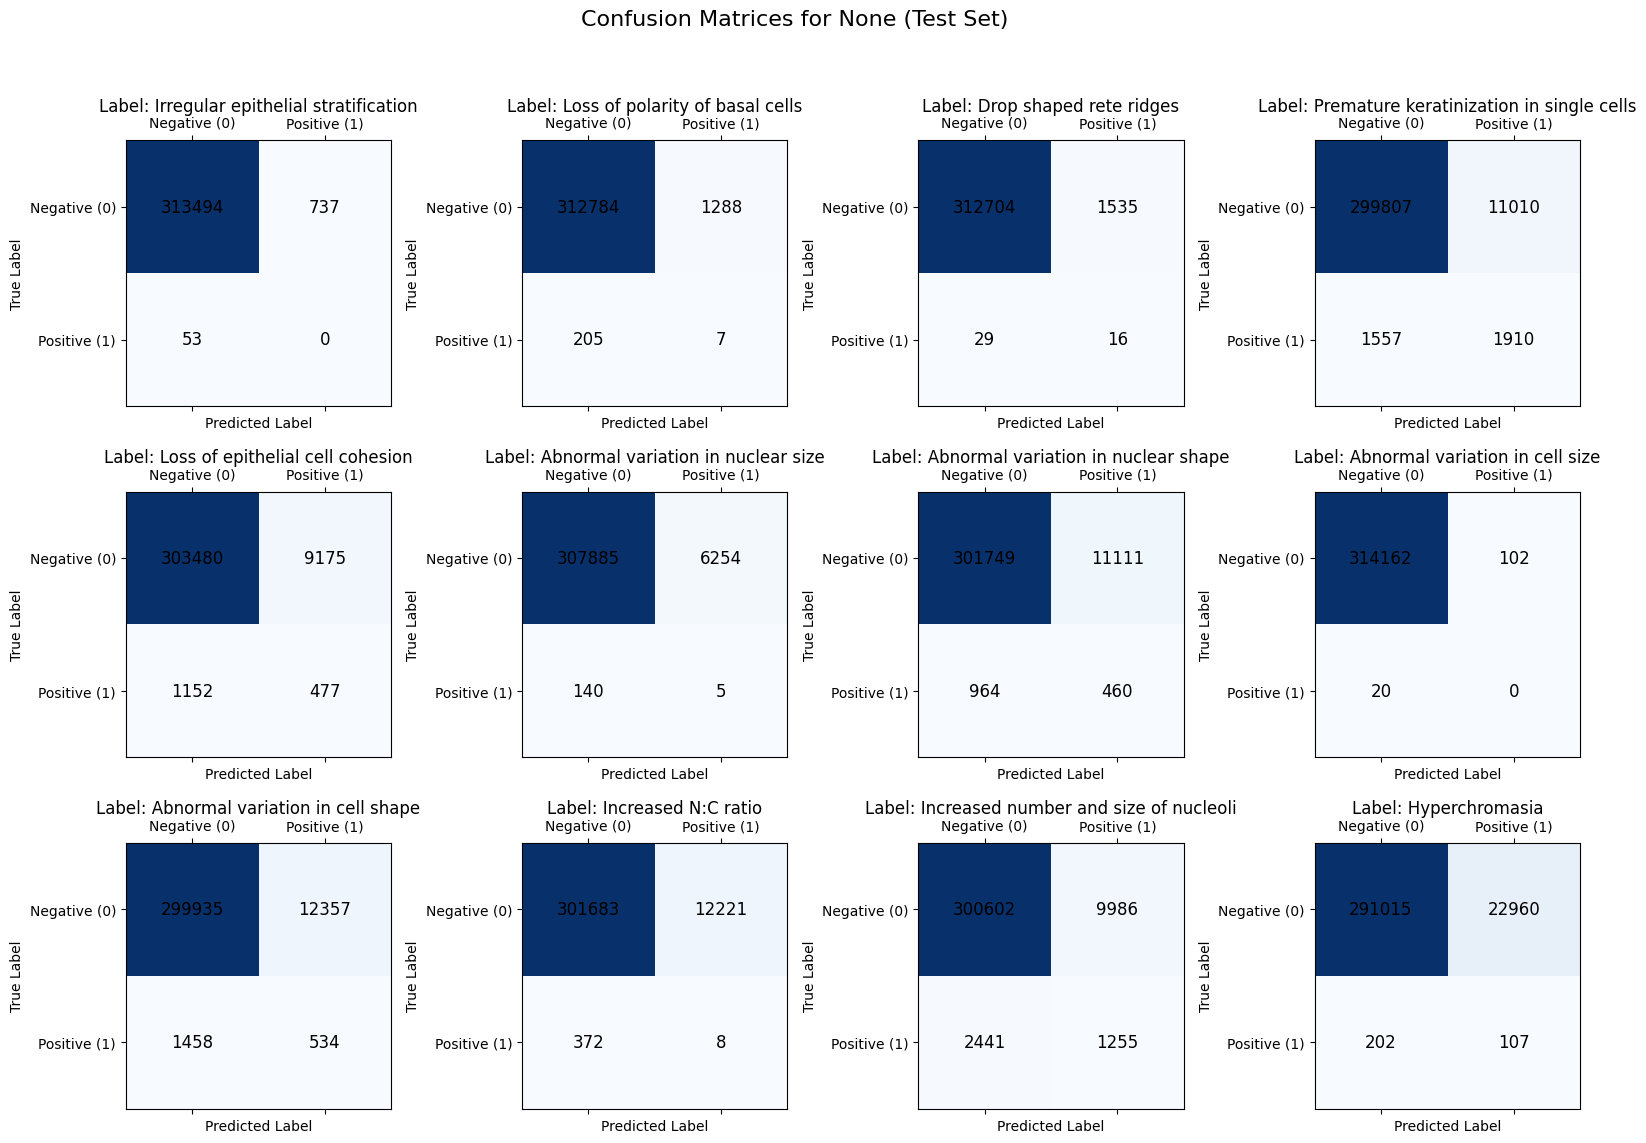



--- Final Test Results for None ---
| Test Micro AUC: 0.9151 | Test Macro AUC: 0.8903 |
-------------------------------------------------



================== FINAL AUROC SUMMARY ==================
Strategy            | Test Micro PRC-AUC| Test Macro PRC-AUC
-------------------------------------------------------
None                | 0.9151          | 0.8903          
-------------------------------------------------------
BEST STRATEGY (None) determined by Macro AUROC: 0.8903


In [11]:
# @title 50% - Square root Weight
# --- 5. Execution Block ---
base_path = str(RP50_DIR)
weight_type = "Sqr"
covertype = "50"

if __name__ == '__main__':
    # Load your DataFrames
    try:
        train_files = [f"{base_path}/final_df_train{i}.csv" for i in range(1, 11)]
        # train_df = pd.concat(
        #     [pd.read_csv(f, low_memory=False) for f in train_files],
        #     ignore_index=True
        # )
        # val_df = pd.read_csv(base_path +'/final_df_val.csv', low_memory=False)
        # test_df = pd.read_csv(base_path +'/final_df_test.csv', low_memory=False)
        # train_df = pd.read_csv(base_path +'/demo_df_train.csv')
        # val_df = pd.read_csv(base_path +'/demo_df_val.csv', low_memory=False)
        # test_df = pd.read_csv(base_path +'/demo_df_test.csv', low_memory=False)
        train_df = pd.concat(
            [pd.read_csv(f, low_memory=False) for f in train_files],
            ignore_index=True
        )
        val_df = pd.read_csv(base_path +'/final_df_val.csv', low_memory=False)
        test_df = pd.read_csv(base_path +'/final_df_test.csv', low_memory=False)

        # Replace Colab-style filepath with DICC filepath
        old_prefix = "/content/ResearchProject_50"
        new_prefix = str(RP50_DIR)

        for df in [train_df, val_df, test_df]:
            df["filepath"] = df["filepath"].astype(str).str.replace(
                old_prefix,
                new_prefix,
                regex=False
            )

        print("\nExample filepath after replacement:")
        print(train_df["filepath"].iloc[0])
        print("Exists:", Path(train_df["filepath"].iloc[0]).exists())

        assert Path(train_df["filepath"].iloc[0]).exists(), "Filepath replacement failed."
    except FileNotFoundError:
        print("ERROR: Please ensure df_train.csv, df_val.csv, and df_test.csv are in the current directory.")
        exit()

    # --- 2. Calculate pos_weight for BCEWithLogitsLoss (from IMbalanced data) ---
    print("Calculating pos_weight for loss function (from full imbalanced set)...")

    # Sum of positive labels for each class
    # print("Training")
    positive_counts = train_df[label_columns].sum()
    print(positive_counts)
    # print("Validation")
    # positive_counts1 = val_df[label_columns].sum()
    # print(positive_counts1)
    # print("Testing")
    # positive_counts2 = test_df[label_columns].sum()
    # print(positive_counts2)

    # Find the total number of 'normal' (all-zero) patches
    print("\n--- Setting up Dynamic 1:1 Sampler ---")

    

    # Identify abnormal (at least one label) vs normal (no labels)
    is_abnormal = train_df[label_columns].sum(axis=1) > 0
    n_abnormal = is_abnormal.sum()
    n_normal = len(train_df) - n_abnormal

    print(f"Dataset Counts: {n_abnormal} Abnormal, {n_normal} Normal")

    # Create weights for the SAMPLER (to force 1:1 balance)
    sample_weights = torch.zeros(len(train_df))
    sample_weights[is_abnormal] = 1.0 / n_abnormal
    sample_weights[~is_abnormal] = 1.0 / n_normal

    # Define the length of one epoch (2 * n_abnormal ensures we see all abnormal patches)
    num_train_samples = int(n_abnormal * 2)

    # Initialize the Sampler
    sampler_generator = torch.Generator()
    sampler_generator.manual_seed(SEED)

    sampler = WeightedRandomSampler(
        weights=sample_weights.double(),
        num_samples=num_train_samples,
        replacement=True,
        generator=sampler_generator
    )
    print(f"Sampler initialized. Epoch length: {num_train_samples} patches.")

    def seed_worker(worker_id):
        worker_seed = SEED + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(SEED)

    # ==============================================================================
    # 2. CALCULATE DAMPENED POS_WEIGHT (PASTE THE NEW CODE HERE)
    # ==============================================================================
    print("\n--- Calculating Dampened pos_weight for Loss Function ---")

    # 1. Get the intrinsic count of positive labels
    positive_counts = train_df[label_columns].sum()

    # 2. Calculate "Effective Negatives" based on the Sampler's 1:1 output
    #    In one epoch, total samples = (2 * n_abnormal)
    effective_negatives = (2 * n_abnormal) - positive_counts

    # 3. Calculate RAW weights first
    raw_weights = effective_negatives / (positive_counts + 1e-6)

    print("Raw Adjusted Weights (Too Aggressive):")
    print(raw_weights)

    # 4. THE FIX: Dampen the weights using Square Root
    #    This prevents the model from predicting "1" for everything.
    pos_weight = torch.sqrt(torch.tensor(raw_weights.values, dtype=torch.float32))

    # 5. Create the Loss Function
    pos_weight = pos_weight.to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    print("\nDampened Weights (Using Sqrt):")
    for label, w in zip(label_columns, pos_weight):
        print(f"  '{label}': {w:.2f}")

    # Initialize Test and Validation Loaders (fixed transform)
    val_dataset = MultiLabelTileDataset(val_df, label_columns, transform=val_test_transform)
    test_dataset = MultiLabelTileDataset(test_df, label_columns, transform=val_test_transform)
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=loader_generator
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
        worker_init_fn=seed_worker,
        generator=loader_generator
    )

    final_results = {}

    # --- Run Loop for Hyperparameter Tuning ---
    for name, train_transform in AUGMENTATION_COMBINATIONS.items():
        # Setup TRAIN Dataset and Loader for current augmentation
        train_dataset = MultiLabelTileDataset(train_df, label_columns, transform=train_transform)
        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            collate_fn=collate_fn,
            shuffle=False,
            worker_init_fn=seed_worker,
            generator=loader_generator
        )

        test_micro_auc, test_macro_auc = train_and_evaluate_run(
            model_name=name,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            num_classes=NUM_CLASSES,
            criterion=criterion,
            optimizer_class=torch.optim.AdamW,
            lr=LEARNING_RATE,
            num_epochs=EPOCHS,
            patience=PATIENCE,
            label_columns=label_columns,
            checkpoint_path=CHECKPOINT_PATH, # Passes the manual checkpoint path
            weight_type=weight_type,
            covertype=covertype
        )

        final_results[name] = {
            'micro': test_micro_auc,
            'macro': test_macro_auc
        }

    # --- Print Summary (Modified) ---
    print("\n\n================== FINAL AUROC SUMMARY ==================")
    # Define header widths (20 + 16 + 16)
    print(f"{'Strategy':<20}| {'Test Micro PRC-AUC':<16}| {'Test Macro PRC-AUC':<16}")
    print("-" * 55)

    best_macro_auc = -1
    best_strategy = ""

    for name, aucs in final_results.items():
        # 1. Retrieve the scores (assuming aucs is now a dictionary)
        micro_score = aucs['micro']
        macro_score = aucs['macro']

        # 2. Format the score into a string (e.g., '0.8500')
        micro_str = f"{micro_score:.4f}"
        macro_str = f"{macro_score:.4f}"

        # 3. Print, applying left-justified padding (the '<16') to the formatted string
        print(f"{name:<20}| {micro_str:<16}| {macro_str:<16}")

        # CHANGE: Track the best model based on MACRO PRC-AUC
        if aucs['macro'] > best_macro_auc:
            best_macro_auc = aucs['macro']
            best_strategy = name

    print("-" * 55)
    print(f"BEST STRATEGY ({best_strategy}) determined by Macro AUROC: {best_macro_auc:.4f}")
    print("=======================================================")

In [12]:
print("--- Positive Class Counts in VALIDATION Set ---")
print(val_df[label_columns].sum())

print("--- Positive Class Counts in Testing Set ---")
print(test_df[label_columns].sum())

--- Positive Class Counts in VALIDATION Set ---
Irregular epithelial stratification          376
Loss of polarity of basal cells              357
Drop shaped rete ridges                       86
Premature keratinization in single cells     449
Loss of epithelial cell cohesion             197
Abnormal variation in nuclear size          2313
Abnormal variation in nuclear shape         1924
Abnormal variation in cell size             1316
Abnormal variation in cell shape            1461
Increased N:C ratio                         1554
Increased number and size of nucleoli       1230
Hyperchromasia                               768
dtype: int64
--- Positive Class Counts in Testing Set ---
Irregular epithelial stratification           53
Loss of polarity of basal cells              212
Drop shaped rete ridges                       45
Premature keratinization in single cells    3467
Loss of epithelial cell cohesion            1629
Abnormal variation in nuclear size           145
Abnormal var

In [13]:
# --- Print Summary (Modified) ---
print("\n\n================== FINAL AUROC SUMMARY ==================")
# Define header widths (20 + 16 + 16)
print(f"{'Strategy':<20}| {'Test Micro PRC-AUC':<16}| {'Test Macro PRC-AUC':<16}")
print("-" * 55)

best_macro_auc = -1
best_strategy = ""

for name, aucs in final_results.items():
    # 1. Retrieve the scores (assuming aucs is now a dictionary)
    micro_score = aucs['micro']
    macro_score = aucs['macro']

    # 2. Format the score into a string (e.g., '0.8500')
    micro_str = f"{micro_score:.4f}"
    macro_str = f"{macro_score:.4f}"

    # 3. Print, applying left-justified padding (the '<16') to the formatted string
    print(f"{name:<20}| {micro_str:<16}| {macro_str:<16}")

    # CHANGE: Track the best model based on MACRO PRC-AUC
    if aucs['macro'] > best_macro_auc:
        best_macro_auc = aucs['macro']
        best_strategy = name

print("-" * 55)
print(f"BEST STRATEGY ({best_strategy}) determined by Macro AUROC: {best_macro_auc:.4f}")
print("=======================================================")



================== FINAL AUROC SUMMARY ==================
Strategy            | Test Micro PRC-AUC| Test Macro PRC-AUC
-------------------------------------------------------
None                | 0.9151          | 0.8903          
-------------------------------------------------------
BEST STRATEGY (None) determined by Macro AUROC: 0.8903


In [ ]:
## Post-hoc pseudo-stage-1 abnormal screening feasibility analysis

上面的实验已经完成了 seed=42 controlled CTransPath baseline 的复现与测试。该 controlled baseline 使用 50% majority-overlap hard labels、square-root weighted BCE、no augmentation、Dynamic 1:1 sampler，并以 validation Macro AUC 作为 checkpoint selection criterion。其最终 test performance 为：Micro AUC = 0.9151，Macro AUC = 0.8903，Micro F1 = 0.0800，Macro F1 = 0.0600，Weighted F1 = 0.1400。该结果作为后续 ablation experiments 和 two-stage design 的主要对照 baseline。

下面的代码不是重新训练模型，也不会改变上面的 controlled baseline 复现结果。它只是一个额外的 post-hoc diagnostic analysis，目的是为后续 Two-Stage Cascade Network 做 feasibility check。具体来说，本实验先导出 controlled baseline 在 test set 上的 12-label prediction probabilities，然后将每个 patch 的 abnormal score 定义为 12 个 OED feature probabilities 中的最大值：

\[
p_{abnormal} = \max(p_1, p_2, ..., p_{12})
\]

如果某个 patch 的 12 个 hard labels 中至少有一个为 1，则该 patch 被定义为 true abnormal patch；如果 12 个 labels 全部为 0，则定义为 normal patch。通过这种方式，原本的 12-label multi-label classification output 被临时转换为一个 pseudo-stage-1 abnormal screening score。

这个小实验的目的不是评估正式 Stage 1 模型，因为这里并没有训练新的 abnormal detector。它只是用现有模型的 probability outputs 来回答一个前置问题：现有 CTransPath baseline 是否已经具备一定的 abnormal-region ranking ability？换句话说，如果只保留 abnormal score 最高的一部分 patches，是否能够覆盖大部分真实 abnormal patches，同时过滤掉大量 normal patches？

随后，本 notebook 会比较两个 probability sources：
1. Controlled Baseline probabilities：用于判断原始 hard-label controlled baseline 是否具备 abnormal screening 能力。
2. Raw Soft AUC-select probabilities：用于判断 soft-label AUC 最好的模型是否更适合 abnormal ranking。

In [10]:
# ============================================================
# Export Controlled Baseline test probabilities for pseudo-stage-1
# ============================================================

import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

controlled_output_dir = Path("/home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug")
controlled_output_dir.mkdir(parents=True, exist_ok=True)

controlled_best_model_path = controlled_output_dir / "best_model_Sqr_50_None.pth"

controlled_probs_path = controlled_output_dir / "test_probs_Sqr_50_None.npy"
controlled_targets_path = controlled_output_dir / "test_targets_hard_Sqr_50_None.npy"

print("Best model exists:", controlled_best_model_path.exists(), "->", controlled_best_model_path)

# Rebuild model and load best controlled baseline checkpoint
model = ctranspath(NUM_CLASSES, checkpoint_path=CHECKPOINT_PATH).to(device)
model.load_state_dict(torch.load(controlled_best_model_path, map_location=device))
model.eval()

test_true = []
test_probs = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Exporting controlled baseline test probabilities"):
        if inputs is None:
            continue

        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)

        test_probs.append(probs.cpu().numpy())
        test_true.append(labels.cpu().numpy())

test_probs = np.concatenate(test_probs, axis=0)
test_true = np.concatenate(test_true, axis=0)

print("test_probs shape:", test_probs.shape)
print("test_true shape:", test_true.shape)

assert test_probs.shape[1] == 12, "Expected 12 probability columns."
assert test_true.shape[1] == 12, "Expected 12 target columns."

np.save(controlled_probs_path, test_probs)
np.save(controlled_targets_path, test_true)

print("Saved controlled test probabilities to:", controlled_probs_path)
print("Saved controlled hard test targets to:", controlled_targets_path)

Best model exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/best_model_Sqr_50_None.pth
Loading weights manually from: /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth


Exporting controlled baseline test probabilities: 100%|██████████| 2456/2456 [15:24<00:00,  2.66it/s]


test_probs shape: (314284, 12)
test_true shape: (314284, 12)
Saved controlled test probabilities to: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_probs_Sqr_50_None.npy
Saved controlled hard test targets to: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_targets_hard_Sqr_50_None.npy


In [11]:
# ============================================================
# Pseudo-Stage-1 Abnormal Screening Analysis
# Controlled Baseline vs Raw Soft AUC-select
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

# ------------------------------------------------------------
# 1. Define paths
# ------------------------------------------------------------

project_root = Path("/home/user/jiangjie/Jiangjie_Project")

controlled_dir = project_root / "outputs" / "kee_reproduction" / "controlled_seed42_50_sqrt_no_aug"
soft_raw_auc_dir = project_root / "outputs" / "soft_label_experiments" / "controlled_soft_raw_seed42_50_sqr_no_aug_aucselect"

analysis_output_dir = project_root / "outputs" / "pseudo_stage1_analysis"
analysis_output_dir.mkdir(parents=True, exist_ok=True)

sources = {
    "Controlled Baseline": {
        "probs": controlled_dir / "test_probs_Sqr_50_None.npy",
        "targets": controlled_dir / "test_targets_hard_Sqr_50_None.npy",
    },
    "Raw Soft AUC-select": {
        "probs": soft_raw_auc_dir / "test_probs_Sqr_SoftRaw_None.npy",
        "targets": soft_raw_auc_dir / "test_targets_hard_Sqr_SoftRaw_None.npy",
    }
}

for source_name, paths in sources.items():
    print("\n", source_name)
    print("probs exists:", paths["probs"].exists(), "->", paths["probs"])
    print("targets exists:", paths["targets"].exists(), "->", paths["targets"])

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def compute_binary_metrics(y_true, selected_mask):
    """
    y_true: binary abnormal labels, shape (N,)
    selected_mask: predicted candidate patches, shape (N,), bool
    """
    y_true = y_true.astype(int)
    selected_mask = selected_mask.astype(bool)

    tp = np.sum((selected_mask == 1) & (y_true == 1))
    fp = np.sum((selected_mask == 1) & (y_true == 0))
    fn = np.sum((selected_mask == 0) & (y_true == 1))
    tn = np.sum((selected_mask == 0) & (y_true == 0))

    selected_patches = np.sum(selected_mask)
    total_patches = len(y_true)
    total_abnormal = np.sum(y_true)

    candidate_retention = selected_patches / total_patches

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    abnormal_density_before = total_abnormal / total_patches
    abnormal_density_after = tp / selected_patches if selected_patches > 0 else 0.0
    enrichment = abnormal_density_after / abnormal_density_before if abnormal_density_before > 0 else 0.0

    return {
        "Total Patches": total_patches,
        "Selected Patches": int(selected_patches),
        "Candidate Retention": candidate_retention,
        "Total True Abnormal": int(total_abnormal),
        "Selected True Abnormal": int(tp),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "Abnormal Precision": precision,
        "Abnormal Recall": recall,
        "Abnormal F1": f1,
        "Abnormal Density Before": abnormal_density_before,
        "Abnormal Density After": abnormal_density_after,
        "Abnormal Enrichment": enrichment,
    }


def run_threshold_sweep(source_name, probs, targets, thresholds):
    """
    p_abnormal = max probability across 12 labels.
    A patch is selected if p_abnormal >= threshold.
    """
    y_abnormal = (targets.sum(axis=1) > 0).astype(int)
    abnormal_score = probs.max(axis=1)

    rows = []

    for threshold in thresholds:
        selected_mask = abnormal_score >= threshold
        metrics = compute_binary_metrics(y_abnormal, selected_mask)

        row = {
            "Probability Source": source_name,
            "Selection Type": "Threshold",
            "Threshold": threshold,
            "Top-k Retention": np.nan,
        }
        row.update(metrics)
        rows.append(row)

    return rows


def run_topk_sweep(source_name, probs, targets, topk_values):
    """
    Select top-k percent patches according to p_abnormal.
    This gives exact candidate retention levels such as top 5%, top 10%, etc.
    """
    y_abnormal = (targets.sum(axis=1) > 0).astype(int)
    abnormal_score = probs.max(axis=1)

    n = len(abnormal_score)
    sorted_indices = np.argsort(-abnormal_score)

    rows = []

    for topk in topk_values:
        keep_n = int(np.ceil(n * topk))
        selected_mask = np.zeros(n, dtype=bool)
        selected_mask[sorted_indices[:keep_n]] = True

        metrics = compute_binary_metrics(y_abnormal, selected_mask)

        threshold_equivalent = abnormal_score[sorted_indices[keep_n - 1]]

        row = {
            "Probability Source": source_name,
            "Selection Type": "Top-k",
            "Threshold": threshold_equivalent,
            "Top-k Retention": topk,
        }
        row.update(metrics)
        rows.append(row)

    return rows


# ------------------------------------------------------------
# 3. Run analysis
# ------------------------------------------------------------

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80, 0.90]
topk_values = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_rows = []
topk_rows = []
overall_rows = []

loaded_targets = {}

for source_name, paths in sources.items():
    probs = np.load(paths["probs"])
    targets = np.load(paths["targets"])

    print("\n==============================")
    print("Source:", source_name)
    print("probs shape:", probs.shape)
    print("targets shape:", targets.shape)

    assert probs.shape == targets.shape, f"Shape mismatch for {source_name}"
    assert probs.shape[1] == 12, f"Expected 12 labels for {source_name}"

    loaded_targets[source_name] = targets

    y_abnormal = (targets.sum(axis=1) > 0).astype(int)
    abnormal_score = probs.max(axis=1)

    abnormal_auroc = roc_auc_score(y_abnormal, abnormal_score)
    abnormal_auprc = average_precision_score(y_abnormal, abnormal_score)

    total_patches = len(y_abnormal)
    total_abnormal = int(y_abnormal.sum())
    abnormal_prevalence = total_abnormal / total_patches

    print("Total patches:", total_patches)
    print("True abnormal patches:", total_abnormal)
    print("Abnormal prevalence:", abnormal_prevalence)
    print("Pseudo-stage-1 abnormal AUROC:", abnormal_auroc)
    print("Pseudo-stage-1 abnormal AUPRC:", abnormal_auprc)

    overall_rows.append({
        "Probability Source": source_name,
        "Total Patches": total_patches,
        "True Abnormal Patches": total_abnormal,
        "Abnormal Prevalence": abnormal_prevalence,
        "Pseudo-stage-1 Abnormal AUROC": abnormal_auroc,
        "Pseudo-stage-1 Abnormal AUPRC": abnormal_auprc,
    })

    threshold_rows.extend(run_threshold_sweep(source_name, probs, targets, thresholds))
    topk_rows.extend(run_topk_sweep(source_name, probs, targets, topk_values))


# Optional sanity check: test targets should be identical if both came from the same hard test set
source_names = list(loaded_targets.keys())
if len(source_names) >= 2:
    same_targets = np.array_equal(loaded_targets[source_names[0]], loaded_targets[source_names[1]])
    print("\nTarget equality check between sources:", same_targets)
    if not same_targets:
        print("Warning: target arrays are not identical. This may indicate different test order or different source files.")

overall_df = pd.DataFrame(overall_rows)
threshold_df = pd.DataFrame(threshold_rows)
topk_df = pd.DataFrame(topk_rows)

# ------------------------------------------------------------
# 4. Format percentage columns for display
# ------------------------------------------------------------

def add_percentage_columns(df):
    df = df.copy()
    for col in [
        "Candidate Retention",
        "Abnormal Precision",
        "Abnormal Recall",
        "Abnormal F1",
        "Abnormal Density Before",
        "Abnormal Density After",
        "Top-k Retention"
    ]:
        if col in df.columns:
            df[col + " (%)"] = df[col] * 100
    return df

overall_display = overall_df.copy()
overall_display["Abnormal Prevalence (%)"] = overall_display["Abnormal Prevalence"] * 100

threshold_display = add_percentage_columns(threshold_df)
topk_display = add_percentage_columns(topk_df)

# ------------------------------------------------------------
# 5. Save results
# ------------------------------------------------------------

overall_path = analysis_output_dir / "pseudo_stage1_overall_auc_auprc.csv"
threshold_path = analysis_output_dir / "pseudo_stage1_threshold_sweep.csv"
topk_path = analysis_output_dir / "pseudo_stage1_topk_sweep.csv"

overall_df.to_csv(overall_path, index=False)
threshold_df.to_csv(threshold_path, index=False)
topk_df.to_csv(topk_path, index=False)

print("\nSaved overall result to:", overall_path)
print("Saved threshold sweep to:", threshold_path)
print("Saved top-k sweep to:", topk_path)

print("\n================ OVERALL =================")
display(overall_display)

print("\n================ THRESHOLD SWEEP =================")
display(
    threshold_display[
        [
            "Probability Source",
            "Threshold",
            "Selected Patches",
            "Candidate Retention (%)",
            "Selected True Abnormal",
            "False Positives",
            "False Negatives",
            "Abnormal Precision (%)",
            "Abnormal Recall (%)",
            "Abnormal F1 (%)",
            "Abnormal Density After (%)",
            "Abnormal Enrichment",
        ]
    ]
)

print("\n================ TOP-K SWEEP =================")
display(
    topk_display[
        [
            "Probability Source",
            "Top-k Retention (%)",
            "Threshold",
            "Selected Patches",
            "Selected True Abnormal",
            "False Positives",
            "False Negatives",
            "Abnormal Precision (%)",
            "Abnormal Recall (%)",
            "Abnormal F1 (%)",
            "Abnormal Density After (%)",
            "Abnormal Enrichment",
        ]
    ]
)


 Controlled Baseline
probs exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_probs_Sqr_50_None.npy
targets exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_targets_hard_Sqr_50_None.npy

 Raw Soft AUC-select
probs exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_aucselect/test_probs_Sqr_SoftRaw_None.npy
targets exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_aucselect/test_targets_hard_Sqr_SoftRaw_None.npy

Source: Controlled Baseline
probs shape: (314284, 12)
targets shape: (314284, 12)
Total patches: 314284
True abnormal patches: 8175
Abnormal prevalence: 0.026011505517302823
Pseudo-stage-1 abnormal AUROC: 0.9129969413965123
Pseudo-stage-1 abnormal AUPRC: 0.15009352393167547

Source: Raw Soft AUC-select

,Probability Source,Total Patches,True Abnormal Patches,Abnormal Prevalence,Pseudo-stage-1 Abnormal AUROC,Pseudo-stage-1 Abnormal AUPRC,Abnormal Prevalence (%)
0,Controlled Baseline,314284,8175,0.026012,0.912997,0.150094,2.601151
1,Raw Soft AUC-select,314284,8175,0.026012,0.892752,0.115065,2.601151



================ THRESHOLD SWEEP =================


,Probability Source,Threshold,Selected Patches,Candidate Retention (%),Selected True Abnormal,False Positives,False Negatives,Abnormal Precision (%),Abnormal Recall (%),Abnormal F1 (%),Abnormal Density After (%),Abnormal Enrichment
0,Controlled Baseline,0.05,137218,43.660511,8150,129068,25,5.939454,99.694190,11.210994,5.939454,2.283395
1,Controlled Baseline,0.10,113380,36.075651,8109,105271,66,7.152055,99.192661,13.342109,7.152055,2.749574
2,Controlled Baseline,0.15,101151,32.184585,8044,93107,131,7.952467,98.397554,14.715621,7.952467,3.057288
3,Controlled Baseline,0.20,91896,29.239796,7969,83927,206,8.671759,97.480122,15.926692,8.671759,3.333817
4,Controlled Baseline,0.25,84051,26.743646,7865,76186,310,9.357414,96.207951,17.055928,9.357414,3.597413
5,Controlled Baseline,0.30,77071,24.522725,7751,69320,424,10.056960,94.813456,18.185017,10.056960,3.866351
6,Controlled Baseline,0.35,70886,22.554759,7602,63284,573,10.724261,92.990826,19.230721,10.724261,4.122891
7,Controlled Baseline,0.40,65012,20.685749,7442,57570,733,11.447117,91.033639,20.336945,11.447117,4.400790
8,Controlled Baseline,0.45,59417,18.905512,7220,52197,955,12.151404,88.318043,21.363475,12.151404,4.671550
9,Controlled Baseline,0.50,53891,17.147230,6923,46968,1252,12.846301,84.685015,22.308510,12.846301,4.938699



================ TOP-K SWEEP =================


,Probability Source,Top-k Retention (%),Threshold,Selected Patches,Selected True Abnormal,False Positives,False Negatives,Abnormal Precision (%),Abnormal Recall (%),Abnormal F1 (%),Abnormal Density After (%),Abnormal Enrichment
0,Controlled Baseline,5.0,0.809498,15715,2488,13227,5687,15.832008,30.434251,20.828799,15.832008,6.086540
1,Controlled Baseline,10.0,0.691258,31429,4949,26480,3226,15.746603,60.538226,24.992425,15.746603,6.053707
2,Controlled Baseline,20.0,0.418761,62857,7367,55490,808,11.720254,90.116208,20.742764,11.720254,4.505796
3,Controlled Baseline,30.0,0.186270,94286,7985,86301,190,8.468914,97.675841,15.586418,8.468914,3.255834
4,Controlled Baseline,40.0,0.068432,125714,8136,117578,39,6.471833,99.522936,12.153351,6.471833,2.488065
5,Controlled Baseline,50.0,0.031515,157142,8163,148979,12,5.194665,99.853211,9.875572,5.194665,1.997064
6,Controlled Baseline,60.0,0.017670,188571,8173,180398,2,4.334177,99.975535,8.308174,4.334177,1.666254
7,Controlled Baseline,70.0,0.011839,219999,8174,211825,1,3.715471,99.987768,7.164708,3.715471,1.428395
8,Controlled Baseline,80.0,0.008954,251428,8175,243253,0,3.251428,100.000000,6.298078,3.251428,1.249996
9,Raw Soft AUC-select,5.0,0.762501,15715,1680,14035,6495,10.690423,20.550459,14.064462,10.690423,4.109883


In [1]:
import numpy as np
from pathlib import Path

controlled_probs = np.load("/home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_probs_Sqr_50_None.npy")
soft_probs = np.load("/home/user/jiangjie/Jiangjie_Project/outputs/soft_label_experiments/controlled_soft_raw_seed42_50_sqr_no_aug_aucselect/test_probs_Sqr_SoftRaw_None.npy")

print("Controlled probs shape:", controlled_probs.shape)
print("Soft probs shape:", soft_probs.shape)

print("Are probabilities exactly identical?", np.array_equal(controlled_probs, soft_probs))
print("Mean absolute difference:", np.mean(np.abs(controlled_probs - soft_probs)))
print("Controlled max score mean:", controlled_probs.max(axis=1).mean())
print("Soft max score mean:", soft_probs.max(axis=1).mean())

Controlled probs shape: (314284, 12)
Soft probs shape: (314284, 12)
Are probabilities exactly identical? False
Mean absolute difference: 0.023511818
Controlled max score mean: 0.18925025
Soft max score mean: 0.16805232


In [ ]:
最终 pseudo-stage-1 analysis 的结果显示，Controlled Baseline 在 abnormal screening 上表现更好，取得 Abnormal AUROC = 0.9130 和 Abnormal AUPRC = 0.1501；而 Raw Soft AUC-select 的 Abnormal AUROC = 0.8928，Abnormal AUPRC = 0.1151。进一步的 Top-k analysis 显示，Controlled Baseline 只保留 top 20% most suspicious patches 时，可以覆盖 90.12% 的真实 abnormal patches；保留 top 30% patches 时，可以覆盖 97.68% 的真实 abnormal patches。这说明现有 baseline 已经能够较好地把 abnormal patches 排到前面。
因此，该 pseudo-stage-1 analysis 支持继续开展正式的 two-stage abnormal-to-feature cascade experiment。也就是说，Stage 1 screening step 有潜力在保留大部分 abnormal patches 的同时过滤掉大量 normal patches，从而为后续 Stage 2 的 fine-grained 12-feature classification 提供更干净、更集中的 candidate patch set。

In [ ]:
在 validation set 上，如果要求 abnormal recall ≥ 95%，Controlled Baseline 最多可以过滤掉多少 patches？

In [10]:
# ============================================================
# Export Controlled Baseline validation probabilities
# for validation-based pseudo-stage-1 threshold selection
# ============================================================

import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

controlled_output_dir = Path("/home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug")
controlled_output_dir.mkdir(parents=True, exist_ok=True)

controlled_best_model_path = controlled_output_dir / "best_model_Sqr_50_None.pth"

val_probs_path = controlled_output_dir / "val_probs_Sqr_50_None.npy"
val_targets_path = controlled_output_dir / "val_targets_hard_Sqr_50_None.npy"

print("Best model exists:", controlled_best_model_path.exists(), "->", controlled_best_model_path)

# Rebuild model and load controlled baseline best checkpoint
model = ctranspath(NUM_CLASSES, checkpoint_path=CHECKPOINT_PATH).to(device)
model.load_state_dict(torch.load(controlled_best_model_path, map_location=device))
model.eval()

val_probs = []
val_true = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Exporting controlled baseline validation probabilities"):
        if inputs is None:
            continue

        inputs = inputs.to(device)
        outputs = model(inputs)
        probs = torch.sigmoid(outputs)

        val_probs.append(probs.cpu().numpy())
        val_true.append(labels.cpu().numpy())

val_probs = np.concatenate(val_probs, axis=0)
val_true = np.concatenate(val_true, axis=0)

print("val_probs shape:", val_probs.shape)
print("val_true shape:", val_true.shape)

assert val_probs.shape[1] == 12, "Expected 12 probability columns."
assert val_true.shape[1] == 12, "Expected 12 target columns."

np.save(val_probs_path, val_probs)
np.save(val_targets_path, val_true)

print("Saved validation probabilities to:", val_probs_path)
print("Saved validation hard targets to:", val_targets_path)

Best model exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/best_model_Sqr_50_None.pth
Loading weights manually from: /home/user/jiangjie/Jiangjie_Project/weights/ctranspath.pth


Exporting controlled baseline validation probabilities: 100%|██████████| 1548/1548 [09:31<00:00,  2.71it/s]

val_probs shape: (198083, 12)
val_true shape: (198083, 12)
Saved validation probabilities to: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/val_probs_Sqr_50_None.npy
Saved validation hard targets to: /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/val_targets_hard_Sqr_50_None.npy


In [11]:
# ============================================================
# Validation-selected pseudo-stage-1 threshold
# Apply selected threshold to test set
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

project_root = Path("/home/user/jiangjie/Jiangjie_Project")
controlled_output_dir = project_root / "outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug"
analysis_output_dir = project_root / "outputs/pseudo_stage1_analysis"
analysis_output_dir.mkdir(parents=True, exist_ok=True)

val_probs_path = controlled_output_dir / "val_probs_Sqr_50_None.npy"
val_targets_path = controlled_output_dir / "val_targets_hard_Sqr_50_None.npy"

test_probs_path = controlled_output_dir / "test_probs_Sqr_50_None.npy"
test_targets_path = controlled_output_dir / "test_targets_hard_Sqr_50_None.npy"

print("val probs exists:", val_probs_path.exists(), "->", val_probs_path)
print("val targets exists:", val_targets_path.exists(), "->", val_targets_path)
print("test probs exists:", test_probs_path.exists(), "->", test_probs_path)
print("test targets exists:", test_targets_path.exists(), "->", test_targets_path)

val_probs = np.load(val_probs_path)
val_targets = np.load(val_targets_path)

test_probs = np.load(test_probs_path)
test_targets = np.load(test_targets_path)

print("val_probs shape:", val_probs.shape)
print("val_targets shape:", val_targets.shape)
print("test_probs shape:", test_probs.shape)
print("test_targets shape:", test_targets.shape)

assert val_probs.shape == val_targets.shape
assert test_probs.shape == test_targets.shape
assert val_probs.shape[1] == 12
assert test_probs.shape[1] == 12

def compute_screening_metrics(y_true, abnormal_score, threshold):
    selected_mask = abnormal_score >= threshold

    total_patches = len(y_true)
    total_abnormal = int(y_true.sum())

    selected_patches = int(selected_mask.sum())
    selected_true_abnormal = int(((selected_mask == 1) & (y_true == 1)).sum())
    false_positives = int(((selected_mask == 1) & (y_true == 0)).sum())
    false_negatives = int(((selected_mask == 0) & (y_true == 1)).sum())

    candidate_retention = selected_patches / total_patches if total_patches > 0 else 0.0
    abnormal_precision = selected_true_abnormal / selected_patches if selected_patches > 0 else 0.0
    abnormal_recall = selected_true_abnormal / total_abnormal if total_abnormal > 0 else 0.0

    if abnormal_precision + abnormal_recall > 0:
        abnormal_f1 = 2 * abnormal_precision * abnormal_recall / (abnormal_precision + abnormal_recall)
    else:
        abnormal_f1 = 0.0

    normal_ratio = false_positives / selected_patches if selected_patches > 0 else 0.0
    abnormal_density_before = total_abnormal / total_patches if total_patches > 0 else 0.0
    abnormal_enrichment = abnormal_precision / abnormal_density_before if abnormal_density_before > 0 else 0.0

    return {
        "Threshold": threshold,
        "Total Patches": total_patches,
        "Total True Abnormal": total_abnormal,
        "Selected Patches": selected_patches,
        "Selected True Abnormal": selected_true_abnormal,
        "False Positives / Normal Selected": false_positives,
        "False Negatives / Abnormal Missed": false_negatives,
        "Candidate Retention": candidate_retention,
        "Abnormal Recall": abnormal_recall,
        "Abnormal Precision": abnormal_precision,
        "Normal Ratio in Candidates": normal_ratio,
        "Abnormal F1": abnormal_f1,
        "Abnormal Enrichment": abnormal_enrichment,
    }

# Binary abnormal labels
val_y_abnormal = (val_targets.sum(axis=1) > 0).astype(int)
test_y_abnormal = (test_targets.sum(axis=1) > 0).astype(int)

# Abnormal score = max 12 feature probabilities
val_abnormal_score = val_probs.max(axis=1)
test_abnormal_score = test_probs.max(axis=1)

# Overall AUROC/AUPRC
val_auroc = roc_auc_score(val_y_abnormal, val_abnormal_score)
val_auprc = average_precision_score(val_y_abnormal, val_abnormal_score)

test_auroc = roc_auc_score(test_y_abnormal, test_abnormal_score)
test_auprc = average_precision_score(test_y_abnormal, test_abnormal_score)

print("\nValidation abnormal AUROC:", val_auroc)
print("Validation abnormal AUPRC:", val_auprc)
print("Test abnormal AUROC:", test_auroc)
print("Test abnormal AUPRC:", test_auprc)

# Threshold sweep on validation
thresholds = [
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.60, 0.70, 0.80, 0.90
]

val_rows = []

for threshold in thresholds:
    metrics = compute_screening_metrics(
        val_y_abnormal,
        val_abnormal_score,
        threshold
    )
    val_rows.append(metrics)

val_threshold_df = pd.DataFrame(val_rows)

# Select threshold:
# among thresholds with validation abnormal recall >= 95%,
# choose the one with lowest candidate retention.
target_recall = 0.95

eligible = val_threshold_df[val_threshold_df["Abnormal Recall"] >= target_recall].copy()

if len(eligible) == 0:
    raise ValueError("No threshold satisfies validation abnormal recall >= 95%.")

selected_row = eligible.sort_values(
    by=["Candidate Retention", "Threshold"],
    ascending=[True, False]
).iloc[0]

selected_threshold = float(selected_row["Threshold"])

print("\nSelected threshold based on validation recall >= 95%:")
print("selected_threshold:", selected_threshold)

# Apply selected validation threshold to test
test_selected_metrics = compute_screening_metrics(
    test_y_abnormal,
    test_abnormal_score,
    selected_threshold
)

test_selected_df = pd.DataFrame([test_selected_metrics])

# Add split labels
val_threshold_df.insert(0, "Split", "Validation")
test_selected_df.insert(0, "Split", "Test")

# Add percentage columns for display
def add_percent_cols(df):
    df = df.copy()
    for col in [
        "Candidate Retention",
        "Abnormal Recall",
        "Abnormal Precision",
        "Normal Ratio in Candidates",
        "Abnormal F1",
    ]:
        df[col + " (%)"] = df[col] * 100
    return df

val_display = add_percent_cols(val_threshold_df)
test_display = add_percent_cols(test_selected_df)

print("\n================ VALIDATION THRESHOLD SWEEP ================")
display(
    val_display[
        [
            "Split",
            "Threshold",
            "Selected Patches",
            "Selected True Abnormal",
            "False Negatives / Abnormal Missed",
            "Candidate Retention (%)",
            "Abnormal Recall (%)",
            "Abnormal Precision (%)",
            "Normal Ratio in Candidates (%)",
            "Abnormal Enrichment",
        ]
    ]
)

print("\n================ TEST RESULT USING VALIDATION-SELECTED THRESHOLD ================")
display(
    test_display[
        [
            "Split",
            "Threshold",
            "Selected Patches",
            "Selected True Abnormal",
            "False Negatives / Abnormal Missed",
            "Candidate Retention (%)",
            "Abnormal Recall (%)",
            "Abnormal Precision (%)",
            "Normal Ratio in Candidates (%)",
            "Abnormal Enrichment",
        ]
    ]
)

# Save results
val_threshold_path = analysis_output_dir / "controlled_baseline_val_threshold_sweep.csv"
test_selected_path = analysis_output_dir / "controlled_baseline_test_result_val_selected_threshold.csv"

val_threshold_df.to_csv(val_threshold_path, index=False)
test_selected_df.to_csv(test_selected_path, index=False)

print("\nSaved validation threshold sweep to:", val_threshold_path)
print("Saved test result with validation-selected threshold to:", test_selected_path)

val probs exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/val_probs_Sqr_50_None.npy
val targets exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/val_targets_hard_Sqr_50_None.npy
test probs exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_probs_Sqr_50_None.npy
test targets exists: True -> /home/user/jiangjie/Jiangjie_Project/outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug/test_targets_hard_Sqr_50_None.npy
val_probs shape: (198083, 12)
val_targets shape: (198083, 12)
test_probs shape: (314284, 12)
test_targets shape: (314284, 12)

Validation abnormal AUROC: 0.8637783859050574
Validation abnormal AUPRC: 0.14085069833966682
Test abnormal AUROC: 0.9129969413965123
Test abnormal AUPRC: 0.15009352393167547

Selected threshold based on validation recall >= 95%:
selected_threshold: 0.2

=========

,Split,Threshold,Selected Patches,Selected True Abnormal,False Negatives / Abnormal Missed,Candidate Retention (%),Abnormal Recall (%),Abnormal Precision (%),Normal Ratio in Candidates (%),Abnormal Enrichment
0,Validation,0.05,116679,4134,6,58.904096,99.855072,3.543054,96.456946,1.695214
1,Validation,0.10,105145,4130,10,53.081284,99.758454,3.927909,96.072091,1.879353
2,Validation,0.15,98045,4099,41,49.496928,99.009662,4.180733,95.819267,2.000319
3,Validation,0.20,91551,4033,107,46.218504,97.415459,4.405195,95.594805,2.107716
4,Validation,0.25,85346,3929,211,43.085979,94.903382,4.603614,95.396386,2.202651
5,Validation,0.30,79000,3821,319,39.882272,92.294686,4.836709,95.163291,2.314178
6,Validation,0.35,72526,3701,439,36.613945,89.396135,5.102998,94.897002,2.441587
7,Validation,0.40,65906,3548,592,33.271911,85.700483,5.383425,94.616575,2.575761
8,Validation,0.45,58884,3387,753,29.726933,81.811594,5.751987,94.248013,2.752103
9,Validation,0.50,51673,3190,950,26.086539,77.053140,6.173437,93.826563,2.953751



================ TEST RESULT USING VALIDATION-SELECTED THRESHOLD ================


,Split,Threshold,Selected Patches,Selected True Abnormal,False Negatives / Abnormal Missed,Candidate Retention (%),Abnormal Recall (%),Abnormal Precision (%),Normal Ratio in Candidates (%),Abnormal Enrichment
0,Test,0.2,91896,7969,206,29.239796,97.480122,8.671759,91.328241,3.333817



Saved validation threshold sweep to: /home/user/jiangjie/Jiangjie_Project/outputs/pseudo_stage1_analysis/controlled_baseline_val_threshold_sweep.csv
Saved test result with validation-selected threshold to: /home/user/jiangjie/Jiangjie_Project/outputs/pseudo_stage1_analysis/controlled_baseline_test_result_val_selected_threshold.csv


In [ ]:
在 validation set 上选择满足 abnormal recall ≥ 95% 的最小 Top-k retention，然后固定这个 Top-k retention 应用到 test set。

In [12]:
# ============================================================
# Validation-selected Top-k pseudo-stage-1 rule
# Apply selected Top-k retention to test set
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score

project_root = Path("/home/user/jiangjie/Jiangjie_Project")
controlled_output_dir = project_root / "outputs/kee_reproduction/controlled_seed42_50_sqrt_no_aug"
analysis_output_dir = project_root / "outputs/pseudo_stage1_analysis"
analysis_output_dir.mkdir(parents=True, exist_ok=True)

val_probs_path = controlled_output_dir / "val_probs_Sqr_50_None.npy"
val_targets_path = controlled_output_dir / "val_targets_hard_Sqr_50_None.npy"

test_probs_path = controlled_output_dir / "test_probs_Sqr_50_None.npy"
test_targets_path = controlled_output_dir / "test_targets_hard_Sqr_50_None.npy"

val_probs = np.load(val_probs_path)
val_targets = np.load(val_targets_path)

test_probs = np.load(test_probs_path)
test_targets = np.load(test_targets_path)

print("val_probs shape:", val_probs.shape)
print("val_targets shape:", val_targets.shape)
print("test_probs shape:", test_probs.shape)
print("test_targets shape:", test_targets.shape)

assert val_probs.shape == val_targets.shape
assert test_probs.shape == test_targets.shape
assert val_probs.shape[1] == 12
assert test_probs.shape[1] == 12

# Binary abnormal labels
val_y_abnormal = (val_targets.sum(axis=1) > 0).astype(int)
test_y_abnormal = (test_targets.sum(axis=1) > 0).astype(int)

# Abnormal score = max 12 feature probabilities
val_abnormal_score = val_probs.max(axis=1)
test_abnormal_score = test_probs.max(axis=1)

def compute_topk_screening_metrics(y_true, abnormal_score, topk_retention):
    y_true = y_true.astype(int)
    n = len(y_true)

    keep_n = int(np.ceil(n * topk_retention))
    sorted_idx = np.argsort(-abnormal_score)

    selected_mask = np.zeros(n, dtype=bool)
    selected_mask[sorted_idx[:keep_n]] = True

    total_patches = n
    total_abnormal = int(y_true.sum())

    selected_patches = int(selected_mask.sum())
    selected_true_abnormal = int(((selected_mask == 1) & (y_true == 1)).sum())
    false_positives = int(((selected_mask == 1) & (y_true == 0)).sum())
    false_negatives = int(((selected_mask == 0) & (y_true == 1)).sum())

    candidate_retention = selected_patches / total_patches if total_patches > 0 else 0.0
    abnormal_precision = selected_true_abnormal / selected_patches if selected_patches > 0 else 0.0
    abnormal_recall = selected_true_abnormal / total_abnormal if total_abnormal > 0 else 0.0

    if abnormal_precision + abnormal_recall > 0:
        abnormal_f1 = 2 * abnormal_precision * abnormal_recall / (abnormal_precision + abnormal_recall)
    else:
        abnormal_f1 = 0.0

    normal_ratio = false_positives / selected_patches if selected_patches > 0 else 0.0
    abnormal_density_before = total_abnormal / total_patches if total_patches > 0 else 0.0
    abnormal_enrichment = abnormal_precision / abnormal_density_before if abnormal_density_before > 0 else 0.0

    threshold_equivalent = abnormal_score[sorted_idx[keep_n - 1]]

    return {
        "Top-k Retention": topk_retention,
        "Threshold Equivalent": threshold_equivalent,
        "Total Patches": total_patches,
        "Total True Abnormal": total_abnormal,
        "Selected Patches": selected_patches,
        "Selected True Abnormal": selected_true_abnormal,
        "False Positives / Normal Selected": false_positives,
        "False Negatives / Abnormal Missed": false_negatives,
        "Candidate Retention": candidate_retention,
        "Abnormal Recall": abnormal_recall,
        "Abnormal Precision": abnormal_precision,
        "Normal Ratio in Candidates": normal_ratio,
        "Abnormal F1": abnormal_f1,
        "Abnormal Enrichment": abnormal_enrichment,
    }

# Top-k sweep on validation
# Use 1% step from 1% to 80% for stable selection
topk_values = np.arange(0.01, 0.81, 0.01)

val_rows = []

for topk in topk_values:
    metrics = compute_topk_screening_metrics(
        val_y_abnormal,
        val_abnormal_score,
        topk
    )
    val_rows.append(metrics)

val_topk_df = pd.DataFrame(val_rows)

# Select Top-k:
# among Top-k retentions with validation abnormal recall >= 95%,
# choose the smallest Top-k retention.
target_recall = 0.95

eligible = val_topk_df[val_topk_df["Abnormal Recall"] >= target_recall].copy()

if len(eligible) == 0:
    raise ValueError("No Top-k retention satisfies validation abnormal recall >= 95%.")

selected_row = eligible.sort_values(
    by=["Top-k Retention"],
    ascending=True
).iloc[0]

selected_topk = float(selected_row["Top-k Retention"])

print("\nSelected Top-k based on validation recall >= 95%:")
print("selected_topk:", selected_topk)

# Apply selected Top-k retention to test
test_selected_metrics = compute_topk_screening_metrics(
    test_y_abnormal,
    test_abnormal_score,
    selected_topk
)

test_selected_df = pd.DataFrame([test_selected_metrics])

# Add split labels
val_topk_df.insert(0, "Split", "Validation")
test_selected_df.insert(0, "Split", "Test")

# Add percentage columns for display
def add_percent_cols(df):
    df = df.copy()
    for col in [
        "Top-k Retention",
        "Candidate Retention",
        "Abnormal Recall",
        "Abnormal Precision",
        "Normal Ratio in Candidates",
        "Abnormal F1",
    ]:
        df[col + " (%)"] = df[col] * 100
    return df

val_display = add_percent_cols(val_topk_df)
test_display = add_percent_cols(test_selected_df)

print("\n================ VALIDATION TOP-K SWEEP ================")
display(
    val_display[
        [
            "Split",
            "Top-k Retention (%)",
            "Threshold Equivalent",
            "Selected Patches",
            "Selected True Abnormal",
            "False Negatives / Abnormal Missed",
            "Candidate Retention (%)",
            "Abnormal Recall (%)",
            "Abnormal Precision (%)",
            "Normal Ratio in Candidates (%)",
            "Abnormal Enrichment",
        ]
    ]
)

print("\n================ TEST RESULT USING VALIDATION-SELECTED TOP-K ================")
display(
    test_display[
        [
            "Split",
            "Top-k Retention (%)",
            "Threshold Equivalent",
            "Selected Patches",
            "Selected True Abnormal",
            "False Negatives / Abnormal Missed",
            "Candidate Retention (%)",
            "Abnormal Recall (%)",
            "Abnormal Precision (%)",
            "Normal Ratio in Candidates (%)",
            "Abnormal Enrichment",
        ]
    ]
)

# Save results
val_topk_path = analysis_output_dir / "controlled_baseline_val_topk_sweep.csv"
test_topk_selected_path = analysis_output_dir / "controlled_baseline_test_result_val_selected_topk.csv"

val_topk_df.to_csv(val_topk_path, index=False)
test_selected_df.to_csv(test_topk_selected_path, index=False)

print("\nSaved validation Top-k sweep to:", val_topk_path)
print("Saved test result with validation-selected Top-k to:", test_topk_selected_path)

val_probs shape: (198083, 12)
val_targets shape: (198083, 12)
test_probs shape: (314284, 12)
test_targets shape: (314284, 12)

Selected Top-k based on validation recall >= 95%:
selected_topk: 0.44

================ VALIDATION TOP-K SWEEP ================


,Split,Top-k Retention (%),Threshold Equivalent,Selected Patches,Selected True Abnormal,False Negatives / Abnormal Missed,Candidate Retention (%),Abnormal Recall (%),Abnormal Precision (%),Normal Ratio in Candidates (%),Abnormal Enrichment
0,Validation,1.0,0.946569,1981,507,3633,1.000086,12.246377,25.593135,74.406865,12.245326
1,Validation,2.0,0.922696,3962,972,3168,2.000172,23.478261,24.533064,75.466936,11.738123
2,Validation,3.0,0.898857,5943,1270,2870,3.000257,30.676329,21.369679,78.630321,10.224565
3,Validation,4.0,0.873970,7924,1478,2662,4.000343,35.700483,18.652196,81.347804,8.924355
4,Validation,5.0,0.851655,9905,1631,2509,5.000429,39.396135,16.466431,83.533569,7.878551
...,...,...,...,...,...,...,...,...,...,...,...
75,Validation,76.0,0.012375,150544,4136,4,76.000464,99.903382,2.747370,97.252630,1.314510
76,Validation,77.0,0.011828,152524,4136,4,77.000045,99.903382,2.711704,97.288296,1.297446
77,Validation,78.0,0.011353,154505,4136,4,78.000131,99.903382,2.676936,97.323064,1.280810
78,Validation,79.0,0.010928,156486,4137,3,79.000217,99.927536,2.643687,97.356313,1.264902



================ TEST RESULT USING VALIDATION-SELECTED TOP-K ================


,Split,Top-k Retention (%),Threshold Equivalent,Selected Patches,Selected True Abnormal,False Negatives / Abnormal Missed,Candidate Retention (%),Abnormal Recall (%),Abnormal Precision (%),Normal Ratio in Candidates (%),Abnormal Enrichment
0,Test,44.0,0.048702,138285,8152,23,44.000013,99.718654,5.895072,94.104928,2.266332



Saved validation Top-k sweep to: /home/user/jiangjie/Jiangjie_Project/outputs/pseudo_stage1_analysis/controlled_baseline_val_topk_sweep.csv
Saved test result with validation-selected Top-k to: /home/user/jiangjie/Jiangjie_Project/outputs/pseudo_stage1_analysis/controlled_baseline_test_result_val_selected_topk.csv


In [13]:
# Print validation-selected Top-k row only

selected_topk = 0.44

selected_val_topk_row = val_topk_df[
    val_topk_df["Top-k Retention"].round(2) == selected_topk
].copy()

selected_val_topk_display = selected_val_topk_row.copy()

for col in [
    "Top-k Retention",
    "Candidate Retention",
    "Abnormal Recall",
    "Abnormal Precision",
    "Normal Ratio in Candidates",
    "Abnormal F1",
]:
    selected_val_topk_display[col + " (%)"] = selected_val_topk_display[col] * 100

display(
    selected_val_topk_display[
        [
            "Split",
            "Top-k Retention (%)",
            "Threshold Equivalent",
            "Selected Patches",
            "Selected True Abnormal",
            "False Negatives / Abnormal Missed",
            "Candidate Retention (%)",
            "Abnormal Recall (%)",
            "Abnormal Precision (%)",
            "Normal Ratio in Candidates (%)",
            "Abnormal Enrichment",
        ]
    ]
)

,Split,Top-k Retention (%),Threshold Equivalent,Selected Patches,Selected True Abnormal,False Negatives / Abnormal Missed,Candidate Retention (%),Abnormal Recall (%),Abnormal Precision (%),Normal Ratio in Candidates (%),Abnormal Enrichment
43,Validation,44.0,0.235458,87157,3963,177,44.000242,95.724638,4.546967,95.453033,2.175548
